In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from numpy import random
import gerrychain   
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.tree import bipartition_tree
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.constraints import within_percent_of_ideal_population
from functools import partial
from gerrychain.metrics import efficiency_gap

import time
import os

In [2]:
## making graph
sc_graph = Graph.from_file("./SC/SC.shp")
gdf = gpd.read_file("./SC/SC.shp")
sc_from_gpd_graph = Graph.from_geodataframe(gdf, adjacency="rook") ## creating graph from geodataframe

In [3]:
sc_graph.nodes[1]

{'boundary_node': False,
 'area': 8648536.552029321,
 'COUNTY': '013',
 'PCODE': '111',
 'CODE_NAME': 'Burton 1B',
 'G20PRER': 160,
 'G20PRED': 650,
 'G20USSR': 142,
 'G20USSD': 679,
 'G20USSCBLE': 7,
 'TOTPOP': 2305,
 'P0020002': 383,
 'P0020005': 591,
 'P0020006': 1203,
 'P0020007': 5,
 'P0020008': 25,
 'P0020009': 1,
 'P0020010': 19,
 'P0020011': 78,
 'VAP': 1623,
 'HVAP': 1534,
 'P0030005': 5,
 'P0030006': 22,
 'P0030007': 1,
 'P0030008': 156,
 'P0030009': 89,
 'P0030010': 84,
 'P0030011': 13,
 'BVAP': 894,
 'P0030016': 1,
 'P0030017': 0,
 'P0030018': 0,
 'P0030019': 7,
 'P0030027': 1,
 'P0030028': 0,
 'P0030029': 0,
 'P0030030': 2,
 'P0030037': 0,
 'P0030038': 0,
 'P0030039': 0,
 'P0030040': 0,
 'P0030041': 0,
 'P0030042': 0,
 'P0030048': 0,
 'P0030049': 0,
 'P0030050': 0,
 'P0030051': 0,
 'P0030052': 0,
 'P0030053': 0,
 'P0030058': 0,
 'P0030059': 0,
 'P0030060': 0,
 'P0030061': 0,
 'P0030064': 0,
 'P0030065': 0,
 'P0030066': 0,
 'P0030067': 0,
 'P0030069': 0,
 'P0030071': 0,
 'A

In [4]:
gdf.columns

Index(['COUNTY', 'PCODE', 'CODE_NAME', 'G20PRER', 'G20PRED', 'G20USSR',
       'G20USSD', 'G20USSCBLE', 'TOTPOP', 'P0020002', 'P0020005', 'P0020006',
       'P0020007', 'P0020008', 'P0020009', 'P0020010', 'P0020011', 'VAP',
       'HVAP', 'P0030005', 'P0030006', 'P0030007', 'P0030008', 'P0030009',
       'P0030010', 'P0030011', 'BVAP', 'P0030016', 'P0030017', 'P0030018',
       'P0030019', 'P0030027', 'P0030028', 'P0030029', 'P0030030', 'P0030037',
       'P0030038', 'P0030039', 'P0030040', 'P0030041', 'P0030042', 'P0030048',
       'P0030049', 'P0030050', 'P0030051', 'P0030052', 'P0030053', 'P0030058',
       'P0030059', 'P0030060', 'P0030061', 'P0030064', 'P0030065', 'P0030066',
       'P0030067', 'P0030069', 'P0030071', 'ALL_BVAP', 'G18GOVD', 'G18GOVR',
       'G18SOSD', 'G18SOSR', 'G18TRED', 'G18TRER', 'G18ATGD', 'G18ATGR',
       'SEND', 'geometry'],
      dtype='object')

In [5]:
print(gdf["SEND"].unique())

['45' '43' '46' '24' '25' '40' '36' '26' '37' '44' '32' '41' '20' '38'
 '42' '14' '17' '27' '29' '30' '34' '9' '8' '7' '13' '12' '6' '2' '5' '28'
 '33' '35' '10' '23' '18' '39' '21' '22' '19' '15' '16' '31' '3' '4' '1'
 '11']


In [6]:
def num_cut_edges(partition):
    return len(partition['cut_edges'])

def democratic_wins(partition):
    return sum(
        1 for district in partition.parts 
        if sum(partition.graph.nodes[node]["G20PRER"] for node in district) > 
           sum(partition.graph.nodes[node]["G20PRED"] for node in district)
    )


elections = [
    Election("G20PRES", {"Democratic": "G20PRED", "Republican": "G20PRER"}),
    Election("G20SEN", {"Democratic": "G20USSD", "Republican": "G20USSR"})]
election_updaters = {election.name: election for election in elections}

my_updaters = {
        "cut_edges": cut_edges,
        "population": Tally("TOTPOP", alias="population"),
        "democratic_wins": democratic_wins,
        "number_cut_edges": num_cut_edges,
    }
my_updaters.update(election_updaters)

In [7]:
initial_partition = Partition(
    graph=sc_from_gpd_graph,
    assignment="SEND",
    updaters = my_updaters
)

In [8]:
ideal_pop = sum(initial_partition["population"].values()) / len(initial_partition)
proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=0.1,
    node_repeats=2,
    method = partial(
                        bipartition_tree,
                        max_attempts=100,
                        allow_pair_reselection=True  # <-- This is the only change
                    )
)

## all used for building markov chain
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)
pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.1)



/opt/anaconda3/envs/gerry/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 20000/20000 [01:33<00:00, 212.92it/s]


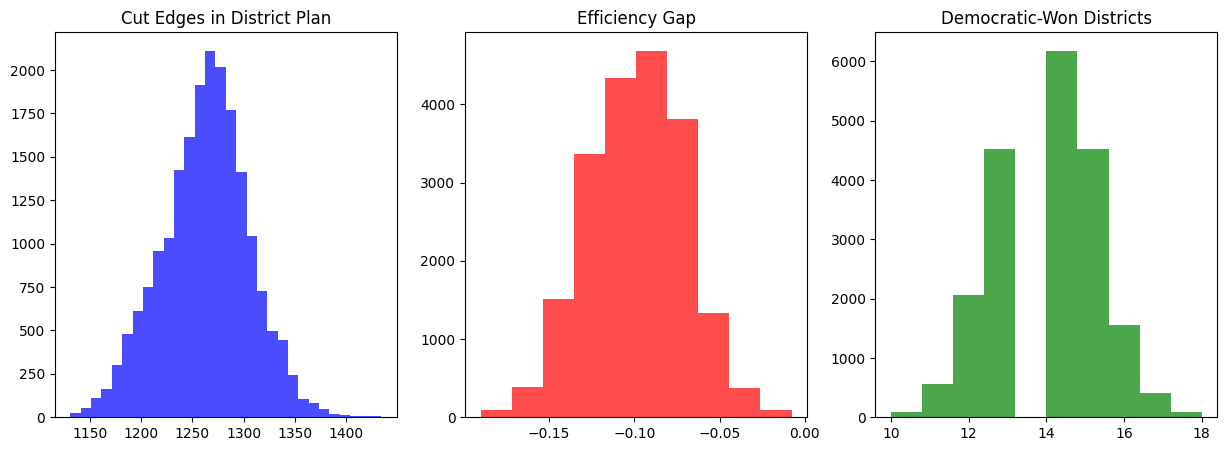

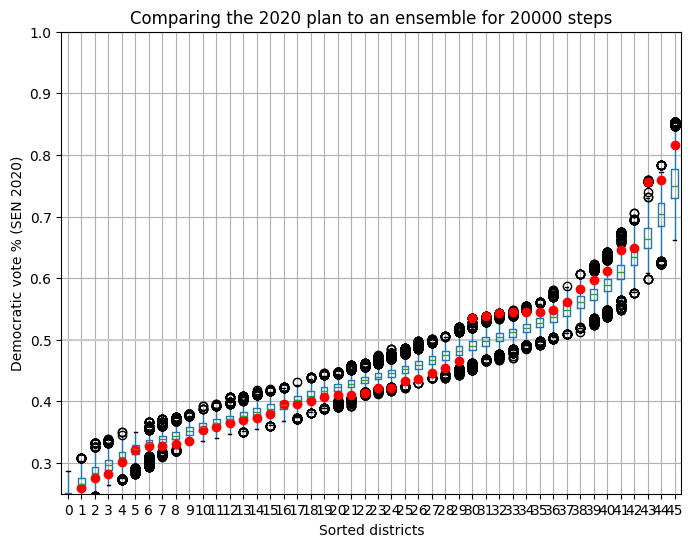

finished run 1 with 20000 steps
20000
[16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 16, 16, 15, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 1

100%|██████████| 40000/40000 [03:02<00:00, 219.58it/s]


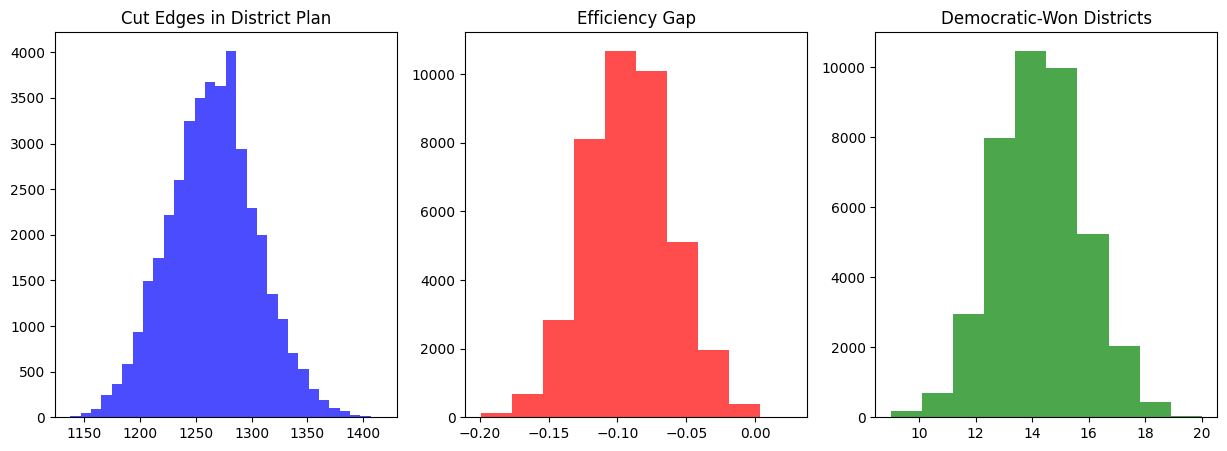

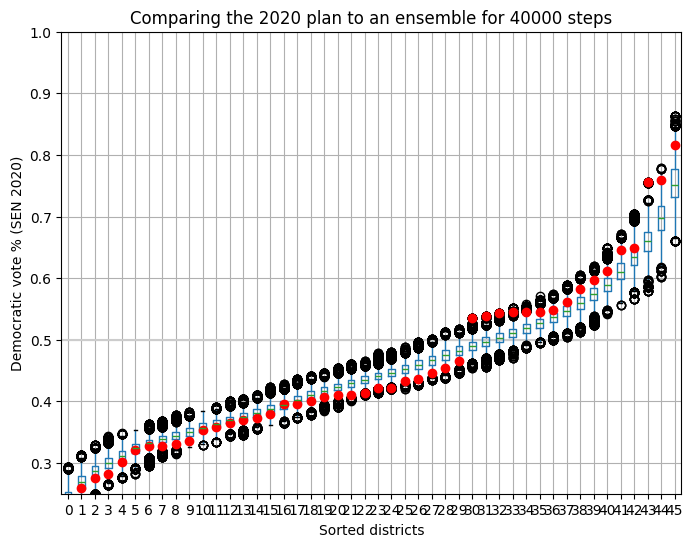

finished run 2 with 40000 steps
40000
[16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 1

In [9]:
'''
chain = MarkovChain(
    proposal=proposal,
    constraints=[within_percent_of_ideal_population(initial_partition, 0.10)], ##Tolerance +- 2%
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=1000
)
'''

## running markov chain random walk (using recom proposal)
num_steps = 20000
for i in range(2):
    chain = MarkovChain(
        proposal=proposal,
        constraints=[compactness_bound, pop_constraint],
        accept=accept.always_accept,
        initial_state=initial_partition,
        total_steps=num_steps ## sample step count for now
    )

    dem_wins = []
    cut_edges_list = []
    efficiency_gap_list = []
    start_time = time.time()

    for step, partition in enumerate(chain):
        
        cut_edges_list.append(partition["number_cut_edges"])
        dem_wins.append(partition["G20SEN"].seats("Democratic")) #OR G20PRES
        efficiency_gap_list.append(partition["G20SEN"].efficiency_gap())
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(cut_edges_list, bins=30, color='blue', alpha=0.7)
    axes[0].set_title("Cut Edges in District Plan")

    axes[1].hist(efficiency_gap_list, bins=10, color='red', alpha=0.7)
    axes[1].set_title("Efficiency Gap")

    axes[2].hist(dem_wins, bins=10, color='green', alpha=0.7)
    axes[2].set_title("Democratic-Won Districts")
    
    ## making df for marginal box plots
    data = pd.DataFrame(
    sorted(partition["G20SEN"].percents("Democratic"))
    for partition in chain.with_progress_bar()
    )
    
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    # Draw boxplot
    data.boxplot(ax=ax, positions=range(len(data.columns)))
    # Draw initial plan's Democratic vote %s (.iloc[0] gives the first row, which corresponds to the initial plan)
    plt.plot(data.iloc[0], "ro")
    # Annotate
    ax.set_title(f"Comparing the 2020 plan to an ensemble for {num_steps} steps")
    ax.set_ylabel("Democratic vote % (SEN 2020)")
    ax.set_xlabel("Sorted districts")
    ax.set_ylim(0.25, 1)
    ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    plt.savefig(f'SCbox_plotSEN2020_{i}.png')
    plt.show()
    

    print(f"finished run {i+1} with {num_steps} steps")
    num_steps *= 2

    print(len(dem_wins))
    print(dem_wins)
    print(len(cut_edges_list))
    print(cut_edges_list)
    print(len(efficiency_gap_list))
    print(efficiency_gap_list)